In [51]:
import pandas as pd 
import seaborn as sns

In [52]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv("https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv")

In [54]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [55]:
print(df.iloc[:,[3,4]].values)
X = df.iloc[:,[3,4]].values

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [57]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

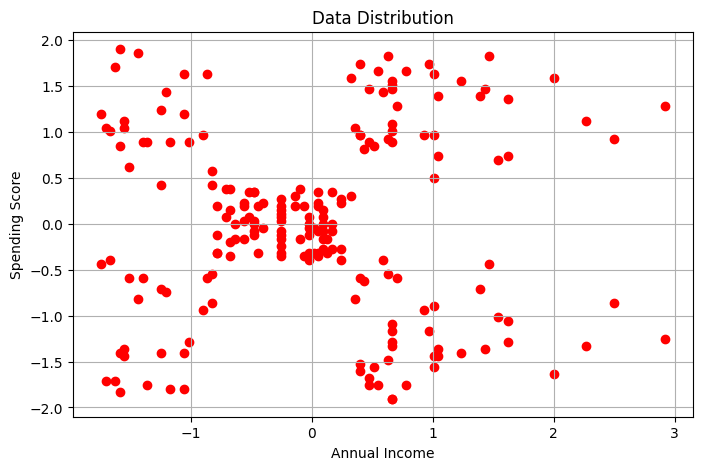

In [58]:
plt.figure(figsize=(8,5))
plt.scatter(x=X_scaled[:,0],y=X_scaled[:,1],c="red")
plt.title("Data Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)

In [59]:
model = KMeans(n_clusters=5, init='k-means++',random_state=42)
kmeans = model.fit(X_scaled)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df["Cluster"]

0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32

In [ ]:

df.replace({1:'Target',0:'Standard',2:"Spendthrift",3:'Careful',4:"Sensible"},inplace=True)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Target,Male,19,15,39,Sensible
1,Spendthrift,Male,21,15,81,Spendthrift
2,Careful,Female,20,16,6,Sensible
3,Sensible,Female,23,16,77,Spendthrift
4,5,Female,31,17,40,Sensible
...,...,...,...,...,...,...
195,196,Female,35,120,79,Target
196,197,Female,45,126,28,Careful
197,198,Male,32,126,74,Target
198,199,Male,32,137,18,Careful


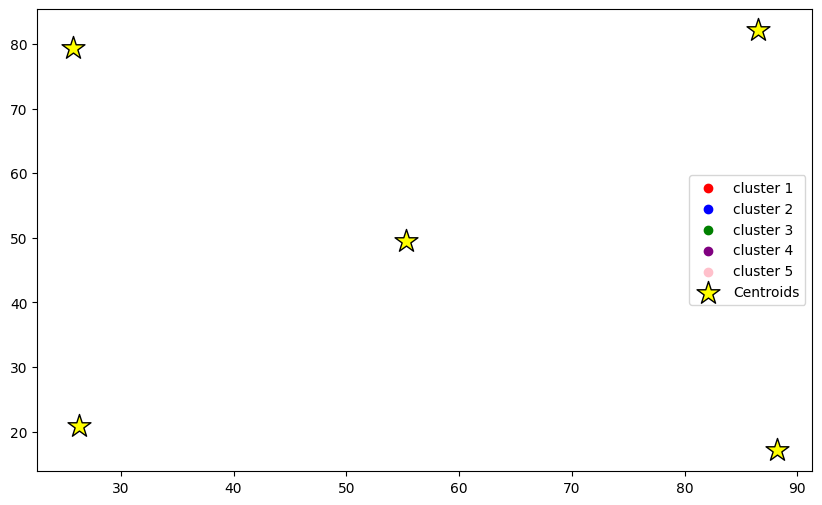

In [61]:
#grouping visualation
plt.figure(figsize=(10,6))
colors = ['red','blue','green','purple','pink']

for i in range(5):
    plt.scatter(x=X[df["Cluster"]==i,0],y=X[df["Cluster"]==i,1],c=colors[i],label = "cluster "+str(i+1))
    


centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0],centroids[:,1],s=300,c="yellow",marker='*',label="Centroids",edgecolors='black')
plt.legend()


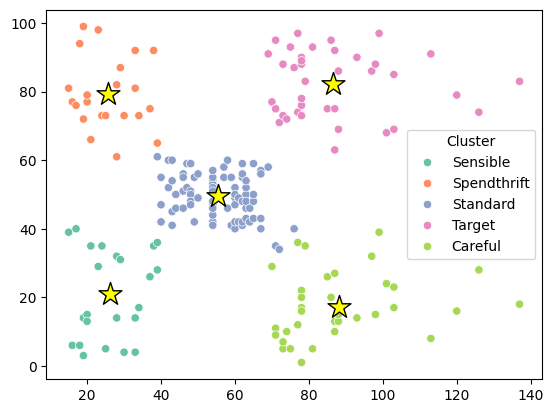

In [62]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=df["Cluster"],palette="Set2")

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0],centroids[:,1],s=300,c="yellow",marker='*',label="Centroids",edgecolors='black')

In [63]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Target,Male,19,15,39,Sensible
1,Spendthrift,Male,21,15,81,Spendthrift
2,Careful,Female,20,16,6,Sensible
3,Sensible,Female,23,16,77,Spendthrift
4,5,Female,31,17,40,Sensible
...,...,...,...,...,...,...
195,196,Female,35,120,79,Target
196,197,Female,45,126,28,Careful
197,198,Male,32,126,74,Target
198,199,Male,32,137,18,Careful
